<div align="center">

# <font size="6">Exploratory Data Analysis — Superstore Dataset</font>

</div>

## 1. Import Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

In [2]:
df = pd.read_csv(r'E:\data\superstore.csv', encoding='latin1')

## 2. Initial Data Overview

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

## 3. Data Quality Check

### Value Counts

In [6]:
print(df["Category"].value_counts())

print("\n", df["Sub-Category"].value_counts())

print('\n', df["Region"].value_counts())

print('\n', df["Segment"].value_counts())

Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

 Sub-Category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64

 Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64

 Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64


### Missing Values and Duplicate Check

In [7]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicate rows: 0


## 4. Data Preparation & Derived Features

### Columns Format Corection

In [8]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%m/%d/%Y")
df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

### Derived Columns

In [9]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month_name()
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days
df[["Order Date", "Ship Date", "Year", "Month", "Shipping Days"]].head()

,Order Date,Ship Date,Year,Month,Shipping Days
0,2016-11-08,2016-11-11,2016,November,3
1,2016-11-08,2016-11-11,2016,November,3
2,2016-06-12,2016-06-16,2016,June,4
3,2015-10-11,2015-10-18,2015,October,7
4,2015-10-11,2015-10-18,2015,October,7


## 5. Univariate Analysis

### Profit Distribution and Boxplot

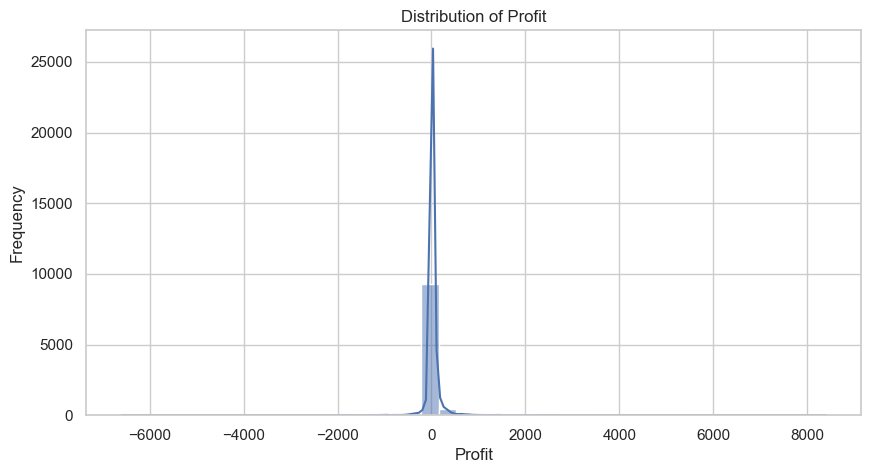

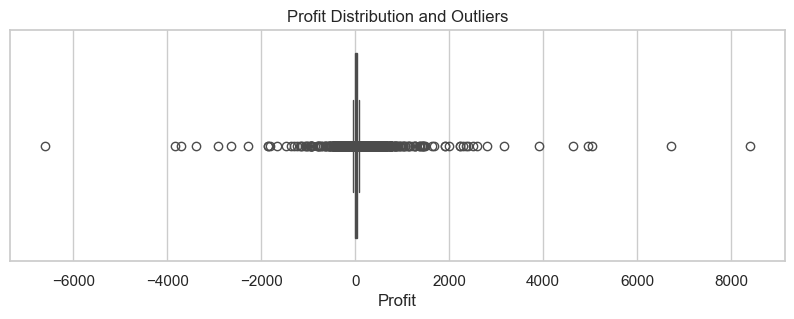

In [10]:
# heatplot 
plt.figure(figsize=(10, 5))

sns.histplot(df["Profit"], bins=40, kde=True)

plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()
print('\n')
# boxplot
plt.figure(figsize=(10, 3))

sns.boxplot(x=df["Profit"])

plt.title("Profit Distribution and Outliers")
plt.xlabel("Profit")
plt.show()

#### **Observation** 
Profit is highly right-skewed, with most observations concentrated near zero. The boxplot shows a large number of potential outliers on both the negative and positive sides, indicating substantial variation in profitability across orders. The mean profit (28.66 Dollar) is considerably higher than the median ($8.67), further confirming the right-skewed distribution.

### Sales Distribution and Boxplot

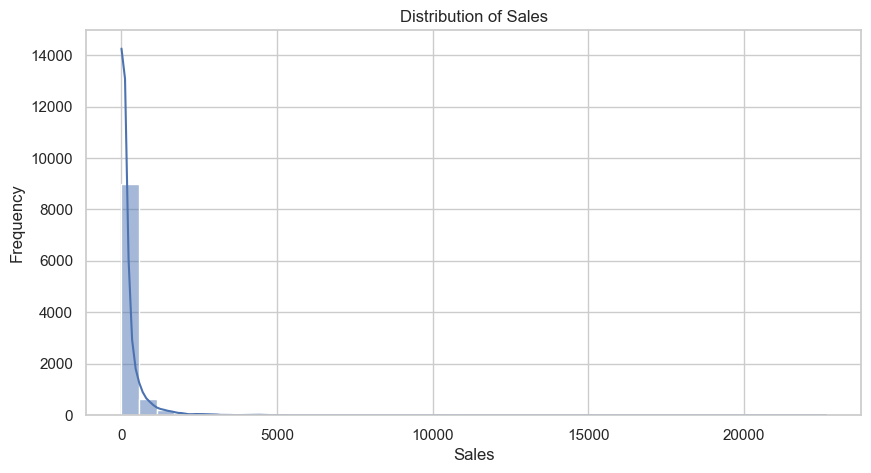

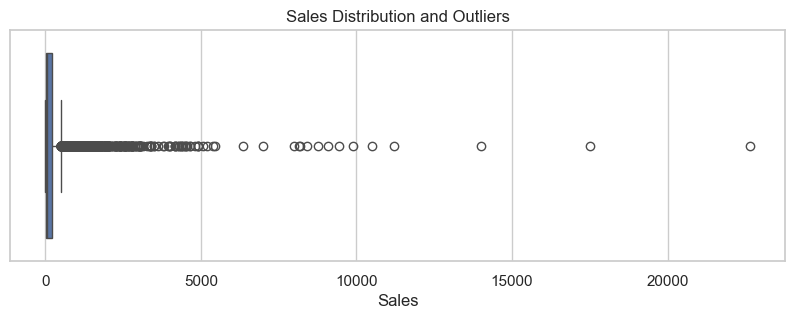

In [11]:
plt.figure(figsize=(10, 5))

sns.histplot(df["Sales"], bins=40, kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()
print('\n')
plt.figure(figsize=(10, 3))

sns.boxplot(x=df["Sales"])

plt.title("Sales Distribution and Outliers")
plt.xlabel("Sales")
plt.show()

#### **Observation** 
Sales are highly right-skewed, with most transactions concentrated at relatively low sales values. The boxplot shows numerous high-value sales outliers, including a small number of transactions exceeding $10,000. This indicates that a relatively small number of orders contribute disproportionately high sales.

## 6. Bivariate Analysis

### Sales vs Profit

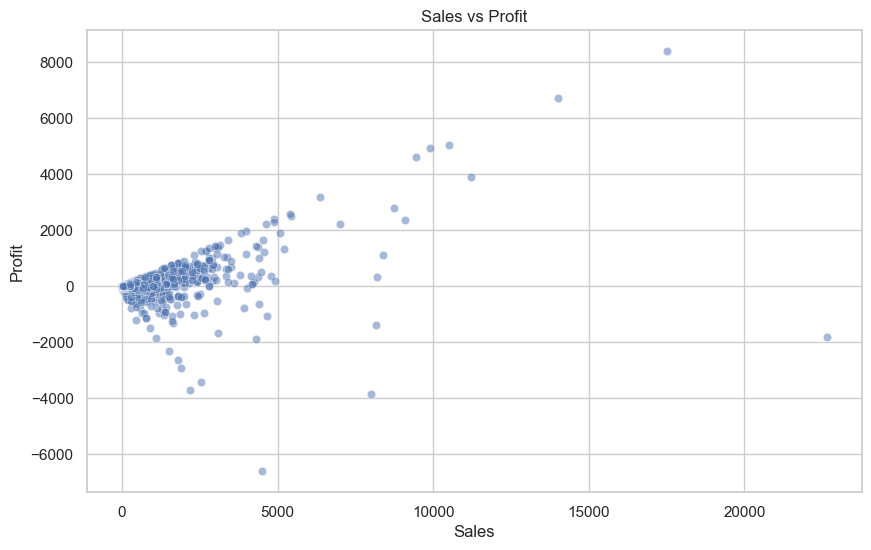

,Sales,Profit
Sales,1.000000,0.479064
Profit,0.479064,1.000000


In [12]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit",
    alpha=0.5
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

df[["Sales", "Profit"]].corr()

#### **Observation:** 
Sales and Profit show a moderate positive correlation (0.479), indicating that higher sales are generally associated with higher profit, but the relationship is not strong. The scatter plot also shows several high-sales transactions with negative profit, suggesting that higher revenue does not always guarantee profitability.

### Discount vs Profit

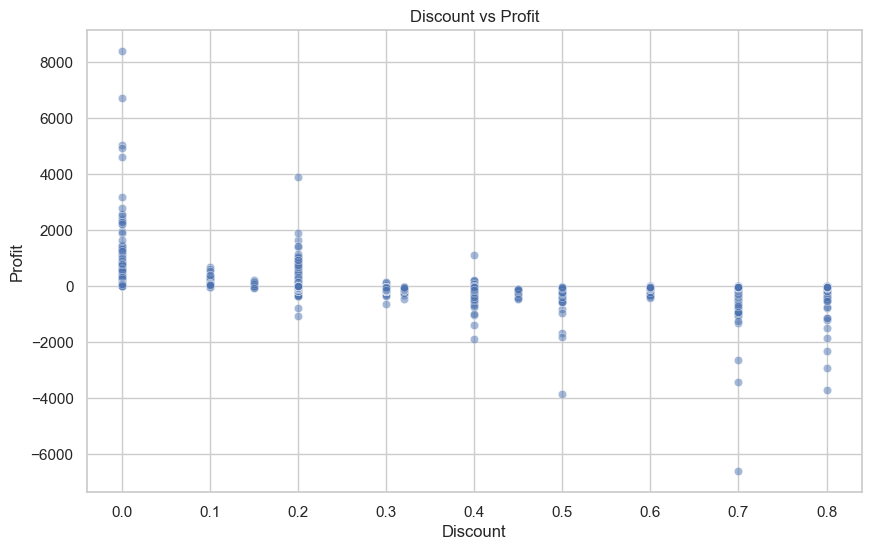

,Discount,Profit
Discount,1.000000,-0.219487
Profit,-0.219487,1.000000


In [13]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    alpha=0.5
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

df[["Discount", "Profit"]].corr()

#### **Observation:** 
Higher discounts are generally associated with lower profitability, although the weak negative correlation (-0.219) indicates that discount is only one of several factors affecting profit.

## 7. Category & Regional Analysis

### Category-wise Sales & Profit

In [14]:
category_summary = df.groupby("Category")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)

category_summary

,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008


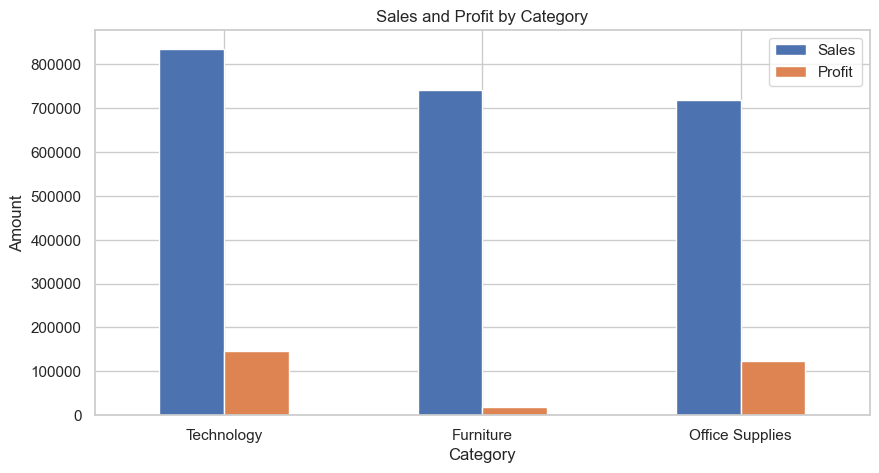

In [15]:
category_summary.plot(kind="bar", figsize=(10, 5))

plt.title("Sales and Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.show()

#### **Obervation:**

- **Technology** generated the highest **Sales (~\$836K)** and **Profit (~\$145K)**.
- **Office Supplies** generated approximately **\$719K in Sales** and **\$122K in Profit**.
- **Furniture** generated approximately **\$742K in Sales** but only **\$18K in Profit**, showing significantly lower profitability compared with the other categories.

> **Furniture is a key profitability concern:** despite generating sales comparable to the other categories, its profit contribution is substantially lower. This suggests that factors such as **discounts, product costs, or specific sub-categories** may be affecting its profitability.

### Region-wise Sales & Profit

In [16]:
region_summary = df.groupby("Region")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)

region_summary

,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
Central,501239.8908,39706.3625
South,391721.9050,46749.4303


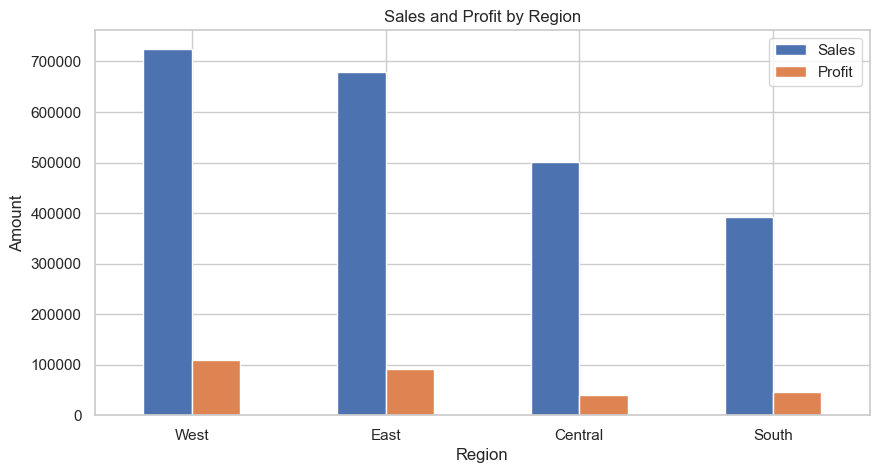

In [17]:
region_summary.plot(kind="bar", figsize=(10, 5))

plt.title("Sales and Profit by Region")
plt.xlabel("Region")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.show()

#### Region-wise Analysis

- **West** generated the highest **Sales (~\$725K)** and **Profit (~\$108K)**.
- **East** ranked second with approximately **\$678K in Sales** and **\$92K in Profit**.
- **Central** generated around **\$501K in Sales** and **\$40K in Profit**.
- **South** had the lowest **Sales (~\$392K)** but generated approximately **\$47K in Profit**.
- > **West is the strongest-performing region**, leading in both Sales and Profit. **Central shows relatively weak profitability compared with its sales volume**, while **South has the lowest sales but maintains a comparatively stronger profit contribution than Central**, suggesting differences in regional profitability.

## 8. Time Trend Analysis

### Sales & Profit Trend Over Time

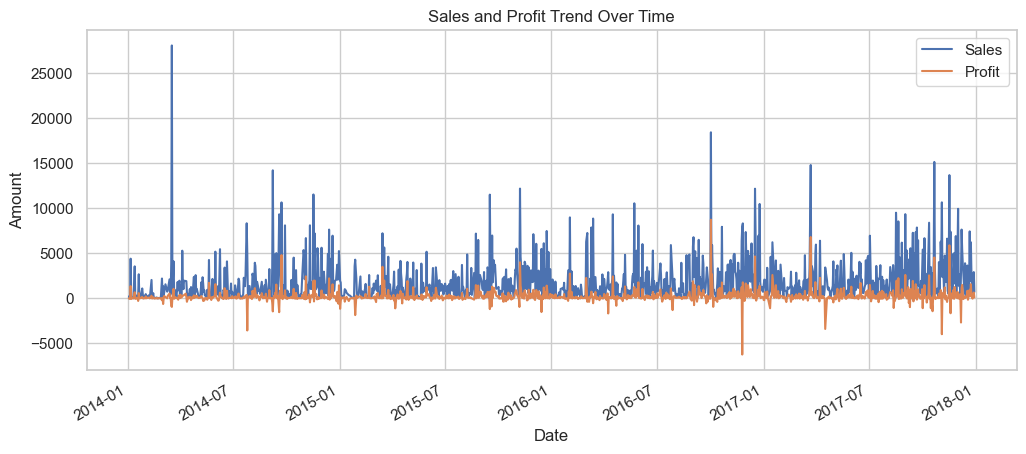

In [18]:
monthly_summary = df.groupby("Order Date")[["Sales", "Profit"]].sum()

monthly_summary.plot(figsize=(12, 5))

plt.title("Sales and Profit Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Amount")
plt.show()

#### **Observation:**

- **Sales and Profit fluctuate considerably over time**, with several noticeable peaks and dips.
- Sales generally remain positive but show occasional **high-value spikes**, particularly during 2014, 2016, and 2017.
- **Profit remains much more volatile than Sales**, with both positive and negative values throughout the period.
- The overall activity appears to increase toward **2017**, with more frequent and larger sales fluctuations.
> **Sales growth does not always translate into stable profitability.** The frequent profit fluctuations and negative-profit periods indicate that profitability is affected by factors beyond sales volume, such as **discounts, product mix, and costs**.

## 9. Correlation Analysis

### Correlation heatmap

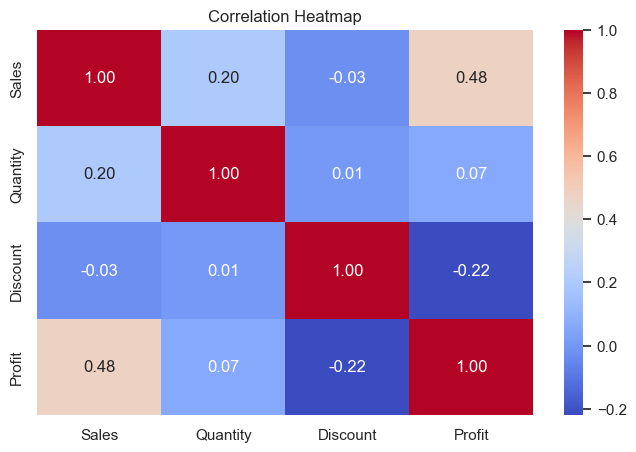

In [19]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    df[["Sales", "Quantity", "Discount", "Profit"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

#### **Observation:**

- **Sales and Profit** show a moderate positive correlation (**0.48**), indicating that higher sales generally tend to be associated with higher profit.
- **Discount and Profit** have a weak negative correlation (**-0.22**), suggesting that higher discounts are generally associated with lower profitability.
- **Sales and Quantity** show a weak positive correlation (**0.20**).
- **Quantity and Profit** have a very weak positive correlation (**0.07**), indicating little linear relationship.
- **Discount and Sales** show almost no linear correlation (**-0.03**).
> **Sales has the strongest relationship with Profit (0.48), while Discount has a weak negative relationship with Profit (-0.22).** This suggests that sales volume is more closely associated with profitability, whereas discounting may negatively affect profit but is not the only factor determining it.

## 10. Key Findings & Conclusion

### Key Findings

- **Technology** generated the highest Sales and Profit, while **Furniture** showed comparatively weak profitability despite substantial sales.
- **West** was the strongest region in both Sales and Profit, while **Central** showed relatively weaker profitability.
- **Sales and Profit** had a moderate positive correlation (**0.48**), indicating that higher sales generally tend to be associated with higher profit.
- **Discount and Profit** had a weak negative correlation (**-0.22**), suggesting that higher discounts are generally associated with lower profitability.
- Sales were **strongly right-skewed**, with several high-value outliers.
- Profit was also **strongly right-skewed**, with substantial variation and both positive and negative values.
- Sales and Profit showed noticeable **fluctuations over time**, indicating that higher sales do not always result in stable profitability.

### Conclusion

The analysis shows that **sales volume alone does not determine profitability**. Product category, region, discount levels, and other factors influence overall performance. The findings highlight **Furniture profitability and discount management** as areas that could warrant further investigation.